<a href="https://colab.research.google.com/github/saharins/ALGORITHM_FINAL/blob/main/Wine_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics as Metrics

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/wine_data.csv')
print(df.head())

    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.6              0.36         0.46            14.1   
1    red            9.5              0.26         0.49             3.7   
2  white            8.3              0.36         0.33            10.2   
3  white            6.5              0.41         0.25             1.5   
4  white            6.1              0.38         0.38            10.6   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.064                 31.0                 174.0   0.9895  3.11   
1      0.027                 31.0                 122.0   0.9913  3.06   
2      0.063                 34.0                 119.0   0.9888  3.19   
3      0.059                 42.0                 143.0   0.9947  3.25   
4      0.015                 48.0                  72.0   0.9945  3.51   

   sulphates  alcohol  quality  
0       0.50      8.7        3  
1       0.62      9.0        5  
2       0.3

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  500 non-null    object 
 1   fixed acidity         500 non-null    float64
 2   volatile acidity      500 non-null    float64
 3   citric acid           500 non-null    float64
 4   residual sugar        500 non-null    float64
 5   chlorides             500 non-null    float64
 6   free sulfur dioxide   500 non-null    float64
 7   total sulfur dioxide  500 non-null    float64
 8   density               500 non-null    float64
 9   pH                    500 non-null    float64
 10  sulphates             500 non-null    float64
 11  alcohol               500 non-null    float64
 12  quality               500 non-null    int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 50.9+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,500.0,7.209400,1.208939,4.000,6.4000,7.2000,8.0000,10.9000
volatile acidity,500.0,0.307000,0.099569,0.010,0.2400,0.3100,0.3700,0.5600
citric acid,500.0,0.337280,0.099136,0.040,0.2700,0.3400,0.4100,0.6500
residual sugar,500.0,10.438200,5.612258,1.000,5.8750,10.2500,15.5000,20.0000
chlorides,500.0,0.051220,0.019289,0.000,0.0370,0.0520,0.0640,0.1120
free sulfur dioxide,500.0,34.370000,15.149790,0.000,24.0000,34.0000,45.0000,94.0000
total sulfur dioxide,500.0,116.798000,51.951970,0.000,79.0000,117.0000,150.5000,277.0000
density,500.0,0.994704,0.003006,0.986,0.9928,0.9947,0.9966,1.0045
pH,500.0,3.195100,0.143119,2.720,3.1000,3.2000,3.3000,3.5600
sulphates,500.0,0.500580,0.101464,0.180,0.4300,0.5000,0.5700,0.8100


In [ ]:
df.isnull().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


In [ ]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
for col in df.columns:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].mean())

df.isnull().sum().sum()

np.int64(0)

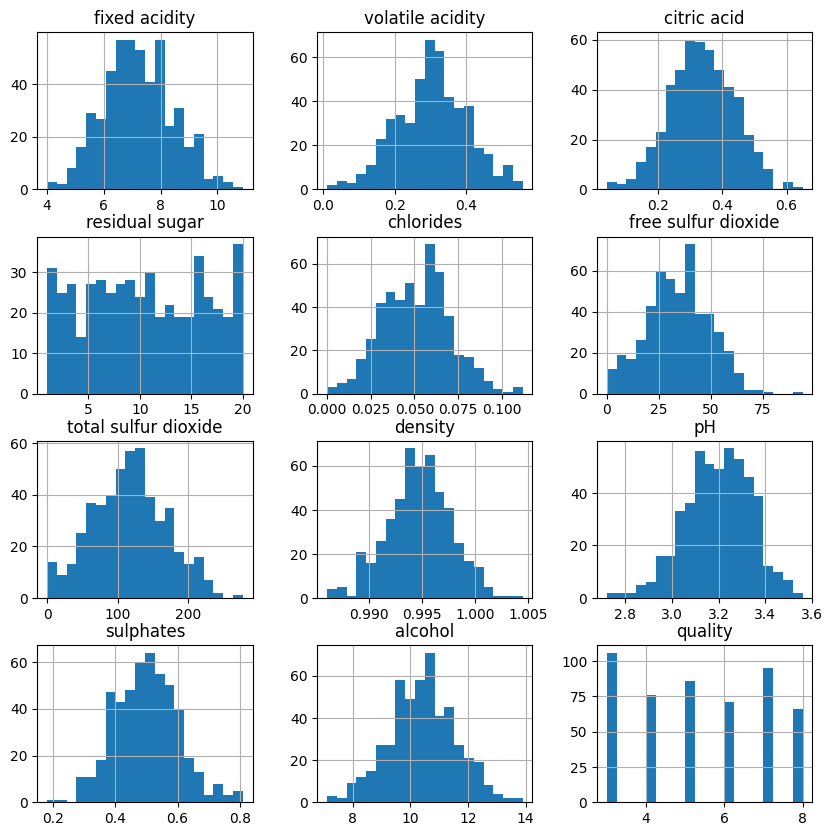

In [ ]:
df.hist(bins=20, figsize=(10, 10))
plt.show()

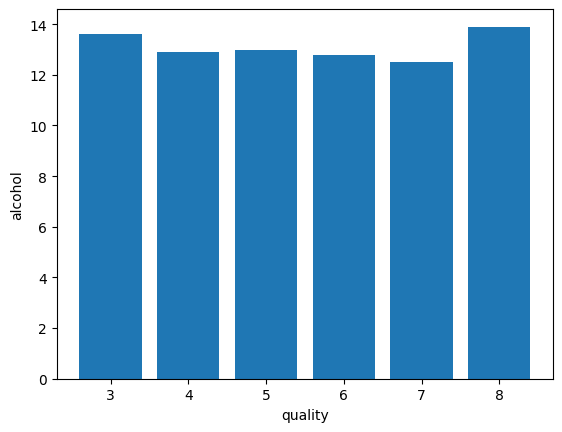

In [ ]:
plt.bar(df['quality'], df['alcohol'])
plt.xlabel('quality')
plt.ylabel('alcohol')
plt.show()

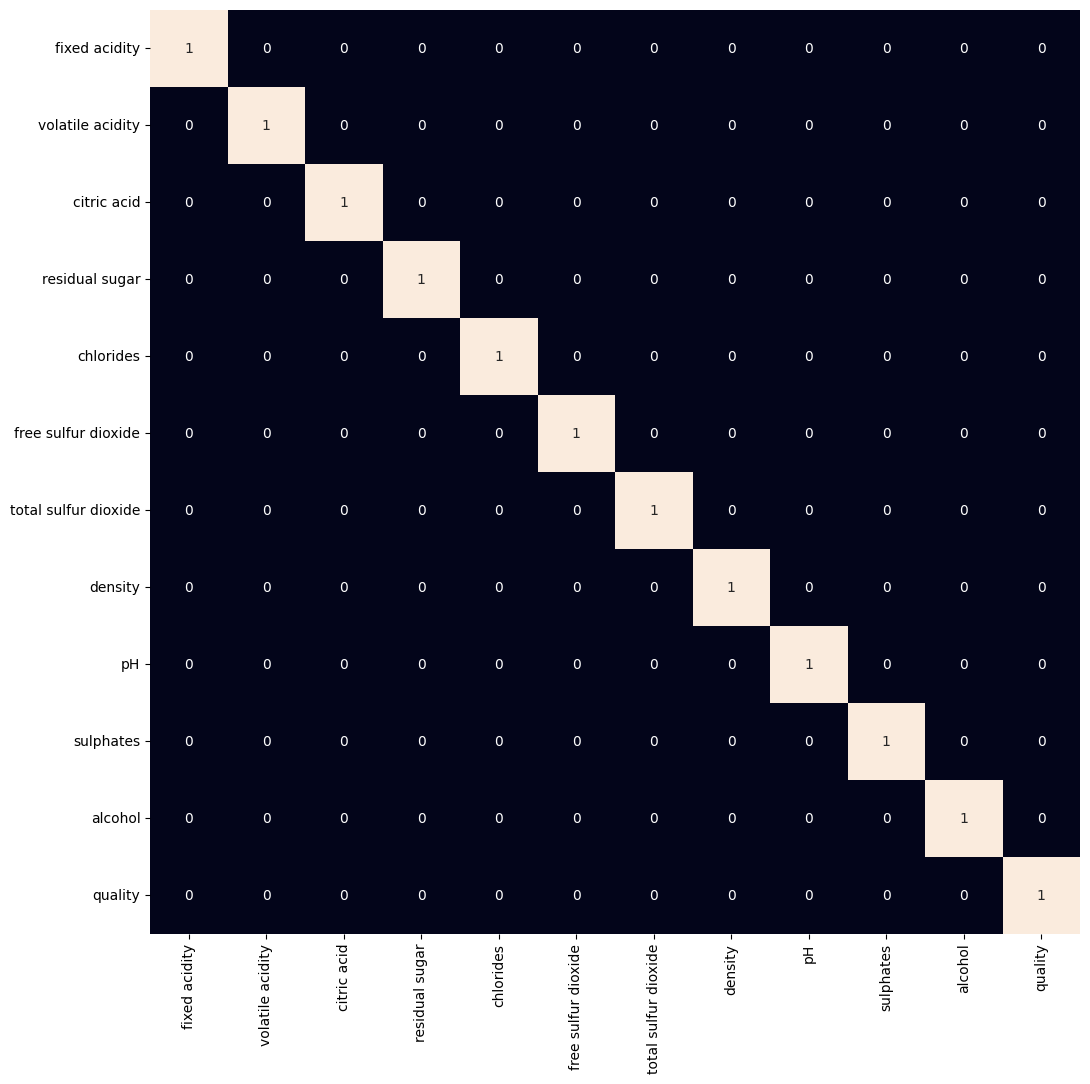

In [ ]:
plt.figure(figsize=(12, 12))

correlation_matrix = df.corr(numeric_only=True)
sb.heatmap(correlation_matrix > 0.7, annot=True, cbar=False)

plt.show()

In [ ]:
df = df.drop('total sulfur dioxide',axis=1)

In [ ]:
df['best quality'] = [1 if x>5 else 0 for x in df.quality]

In [ ]:
df.replace({'white': 1, 'red': 0},inplace=True)

In [ ]:
features = df.drop(['quality','best quality'],axis=1)
target = df['best quality']
xtrain,xtest,ytrain,ytest = train_test_split(features,target,test_size=0.2,random_state=40)
xtrain.shape,xtest.shape

((400, 11), (100, 11))

In [ ]:
norm = MinMaxScaler()
xtrain = norm.fit_transform(xtrain)
xtest = norm.transform(xtest)

In [ ]:
from sklearn import metrics as Metrics

models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf')]
for i in range(3):
    models[i].fit(xtrain, ytrain)
    print(f'{models[i]} :')

    train_acc = Metrics.roc_auc_score(ytrain, models[i].predict(xtrain))
    val_acc = Metrics.roc_auc_score(ytest, models[i].predict(xtest))

    print('Training Accuracy : ', train_acc)
    print('Validation Accuracy : ', val_acc)
    print()


LogisticRegression() :
Training Accuracy :  0.5255813953488372
Validation Accuracy :  0.3809714973906062

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) :
Training Accuracy :  1.0
Validation Accuracy :  0.523083099156965

SVC() :
Training Accuracy :  0.6695160276555625
Validation Accur

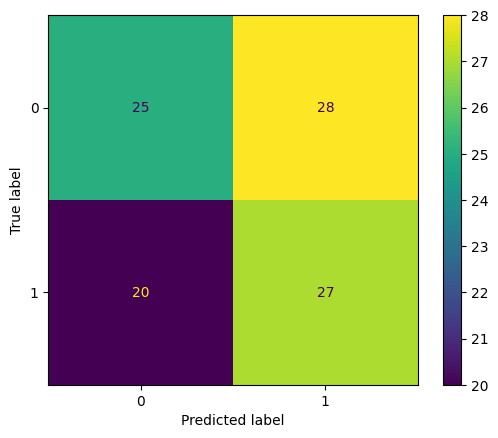

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(models[1], xtest, ytest)
plt.show()

In [ ]:
print(Metrics.classification_report(ytest,
                                    models[1].predict(xtest)))

              precision    recall  f1-score   support

           0       0.56      0.47      0.51        53
           1       0.49      0.57      0.53        47

    accuracy                           0.52       100
   macro avg       0.52      0.52      0.52       100
weighted avg       0.53      0.52      0.52       100

